# Proyecto Final — Analítica y Visualización de Datos
### Evaluación y Preprocesamiento de Datos

**Dataset:** Concentraciones de Contaminantes en el Aire — SEDEMA / SIMAT, CDMX  
**Fuente:** https://datos.cdmx.gob.mx/dataset/red-automatica-de-monitoreo-atmosferico  
**Archivo:** `rama_2023_05.csv`  
**Periodo:** 01/01/2015 — 31/05/2023 | **Granularidad:** Promedio diario por contaminante

---
### Contenido
1. Carga y exploración inicial
2. Escalas de datos
3. Representación matricial
4. Manejo de errores y valores faltantes
5. Medidas de disimilitud y norma matricial
6. Medidas de similitud (Jaccard, coseno, Sørensen-Dice)
7. Detección y manejo de outliers
8. Filtrado de señales
9. Transformación y normalización
10. Construcción de perfiles mensuales
11. Exportación de datasets procesados

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats, signal
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_theme(style='whitegrid')

print('Librerías cargadas correctamente ')

Librerías cargadas correctamente 


## 2. Carga y exploración inicial

In [2]:
df = pd.read_csv('rama_2023_05.csv', parse_dates=['fecha'], dayfirst=True)

CONTAMINANTES = ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2']

print('RESUMEN ESTRUCTURAL DEL DATASET\n')
print(f'  Filas          : {df.shape[0]:,}')
print(f'  Columnas       : {df.shape[1]}')
print(f'  Periodo        : {df["fecha"].min().date()}  →  {df["fecha"].max().date()}')
print(f'  Años cubiertos : {df["fecha"].dt.year.nunique()}  ({df["fecha"].dt.year.min()}–{df["fecha"].dt.year.max()})')
print(f'  Contaminantes  : {CONTAMINANTES}')
print()
print('Primeras filas:')
df.head()

RESUMEN ESTRUCTURAL DEL DATASET

  Filas          : 3,073
  Columnas       : 9
  Periodo        : 2015-01-01  →  2023-05-31
  Años cubiertos : 9  (2015–2023)
  Contaminantes  : ['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2']

Primeras filas:


,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,2015-01-01,1.050696,22.765528,24.225155,46.987578,23.175150,105.573684,78.953405,11.554723
1,2015-01-02,0.807585,32.249608,21.554160,53.800628,17.268366,36.687845,15.449438,1.895052
2,2015-01-03,0.640755,21.686916,19.394081,41.071651,15.486486,29.269022,12.915129,1.436937
3,2015-01-04,0.726940,24.606272,19.560976,44.165505,17.329032,39.961538,16.838284,1.809061
4,2015-01-05,0.530815,11.443182,20.990260,32.439935,14.470588,31.855643,12.667774,8.315789


In [3]:
# Estadísticas descriptivas
print('Estadísticas descriptivas por contaminante:')
df[CONTAMINANTES].describe().round(3)

Estadísticas descriptivas por contaminante:


,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
count,3073.000,3073.000,3073.000,3073.000,3073.000,3073.000,3073.000,3073.000
mean,0.482,14.712,23.030,37.997,30.486,41.893,21.327,3.690
std,0.205,8.858,6.755,14.796,9.023,16.047,8.796,3.490
min,0.116,1.168,8.062,9.983,3.226,8.218,2.849,0.630
25%,0.327,8.019,18.188,26.938,23.923,29.484,15.345,1.557
50%,0.444,12.670,22.422,35.880,29.838,40.041,20.550,2.484
75%,0.597,19.386,26.854,46.740,36.216,52.709,26.213,4.377
max,1.832,75.807,72.193,148.006,67.444,115.334,86.910,31.462


In [4]:
# Tipos de datos
print('Tipos de datos:')
print(df.dtypes)

Tipos de datos:
fecha    datetime64[ns]
CO              float64
NO              float64
NO2             float64
NOX             float64
O3              float64
PM10            float64
PM25            float64
SO2             float64
dtype: object


## 2. Escalas de datos

Clasificamos cada variable del dataset según su **escala de medición**,
lo que determina qué operaciones estadísticas son válidas sobre ella.

In [5]:
escalas = pd.DataFrame({
    'Variable':       ['fecha', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM25', 'SO2'],
    'Escala':         ['Intervalo', 'Razón', 'Razón', 'Razón', 'Razón',
                       'Razón', 'Razón', 'Razón', 'Razón'],
    'Tipo Python':    ['datetime64', 'float64', 'float64', 'float64', 'float64',
                       'float64', 'float64', 'float64', 'float64'],
    'Unidad':         ['—', 'ppm', 'ppb', 'ppb', 'ppb', 'ppb', 'µg/m³', 'µg/m³', 'ppb'],
    'Justificación':  [
        'Diferencias con sentido; sin cero absoluto natural en el calendario',
        'Cero absoluto = ausencia de CO; razones válidas (2 ppm = doble de 1 ppm)',
        'Cero absoluto = ausencia de NO; cocientes interpretables',
        'Cero absoluto = ausencia de NO2; cocientes interpretables',
        'Suma de NO + NO2; cero absoluto; cocientes válidos',
        'Cero absoluto = ausencia de ozono; cocientes interpretables',
        'Masa por unidad de volumen; cero absoluto; cocientes válidos',
        'Masa por unidad de volumen; cero absoluto; cocientes válidos',
        'Cero absoluto = ausencia de SO2; cocientes interpretables'
    ]
})

print('Clasificación de variables por escala de medición:')
print(escalas.to_string(index=False))

Clasificación de variables por escala de medición:
Variable    Escala Tipo Python Unidad                                                            Justificación
   fecha Intervalo  datetime64      —      Diferencias con sentido; sin cero absoluto natural en el calendario
      CO     Razón     float64    ppm Cero absoluto = ausencia de CO; razones válidas (2 ppm = doble de 1 ppm)
      NO     Razón     float64    ppb                 Cero absoluto = ausencia de NO; cocientes interpretables
     NO2     Razón     float64    ppb                Cero absoluto = ausencia de NO2; cocientes interpretables
     NOX     Razón     float64    ppb                       Suma de NO + NO2; cero absoluto; cocientes válidos
      O3     Razón     float64    ppb              Cero absoluto = ausencia de ozono; cocientes interpretables
    PM10     Razón     float64  µg/m³             Masa por unidad de volumen; cero absoluto; cocientes válidos
    PM25     Razón     float64  µg/m³             Masa por un

## 3. Representación matricial

Construimos la **matriz de perfiles mensuales** M donde:
- Cada **fila** es un mes (año-mes)
- Cada **columna** es un contaminante
- El **valor** es el promedio de concentración en ese mes

Esta matriz es la base para PCA, MDS, distancias y similitudes.

In [6]:
# Agregar columnas de tiempo
df['anio']    = df['fecha'].dt.year
df['mes']     = df['fecha'].dt.month
df['anio_mes'] = df['fecha'].dt.to_period('M')
df['estacion_anio'] = pd.cut(
    df['mes'],
    bins=[0, 3, 6, 9, 12],
    labels=['Invierno', 'Primavera', 'Verano', 'Otoño']
)

# Matriz M: perfiles mensuales
M = df.groupby('anio_mes')[CONTAMINANTES].mean().round(4)

print(f'Matriz M (perfiles mensuales):')
print(f'  Shape : {M.shape}  →  {M.shape[0]} meses × {M.shape[1]} contaminantes')
print(f'  Periodo: {M.index.min()} → {M.index.max()}')
print()
M.head(12)

Matriz M (perfiles mensuales):
  Shape : (101, 8)  →  101 meses × 8 contaminantes
  Periodo: 2015-01 → 2023-05



,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
anio_mes,,,,,,,,
2015-01,0.8465,24.4757,28.4567,52.9337,24.6892,53.9715,26.7040,4.7238
2015-02,0.7964,23.5305,27.9614,51.4771,25.8703,50.9925,23.6761,4.5908
2015-03,0.6513,16.7152,23.3001,40.0035,26.5051,39.6902,19.7500,3.1612
2015-04,0.6787,16.3829,25.9185,42.2989,36.9165,50.3574,27.7387,4.1208
2015-05,0.6973,15.4851,26.1106,41.5972,33.1516,37.9026,24.5399,2.6604
2015-06,0.6346,12.9779,23.9957,36.9750,28.7305,38.8672,24.1419,4.6165
2015-07,0.6556,15.4526,24.1162,39.5750,29.9125,37.0491,21.3029,3.0548
2015-08,0.5848,11.8292,21.8719,33.7034,31.0319,31.4179,17.7659,3.1181
2015-09,0.7168,15.4702,24.7406,40.2105,27.2000,32.3475,19.7805,3.2686


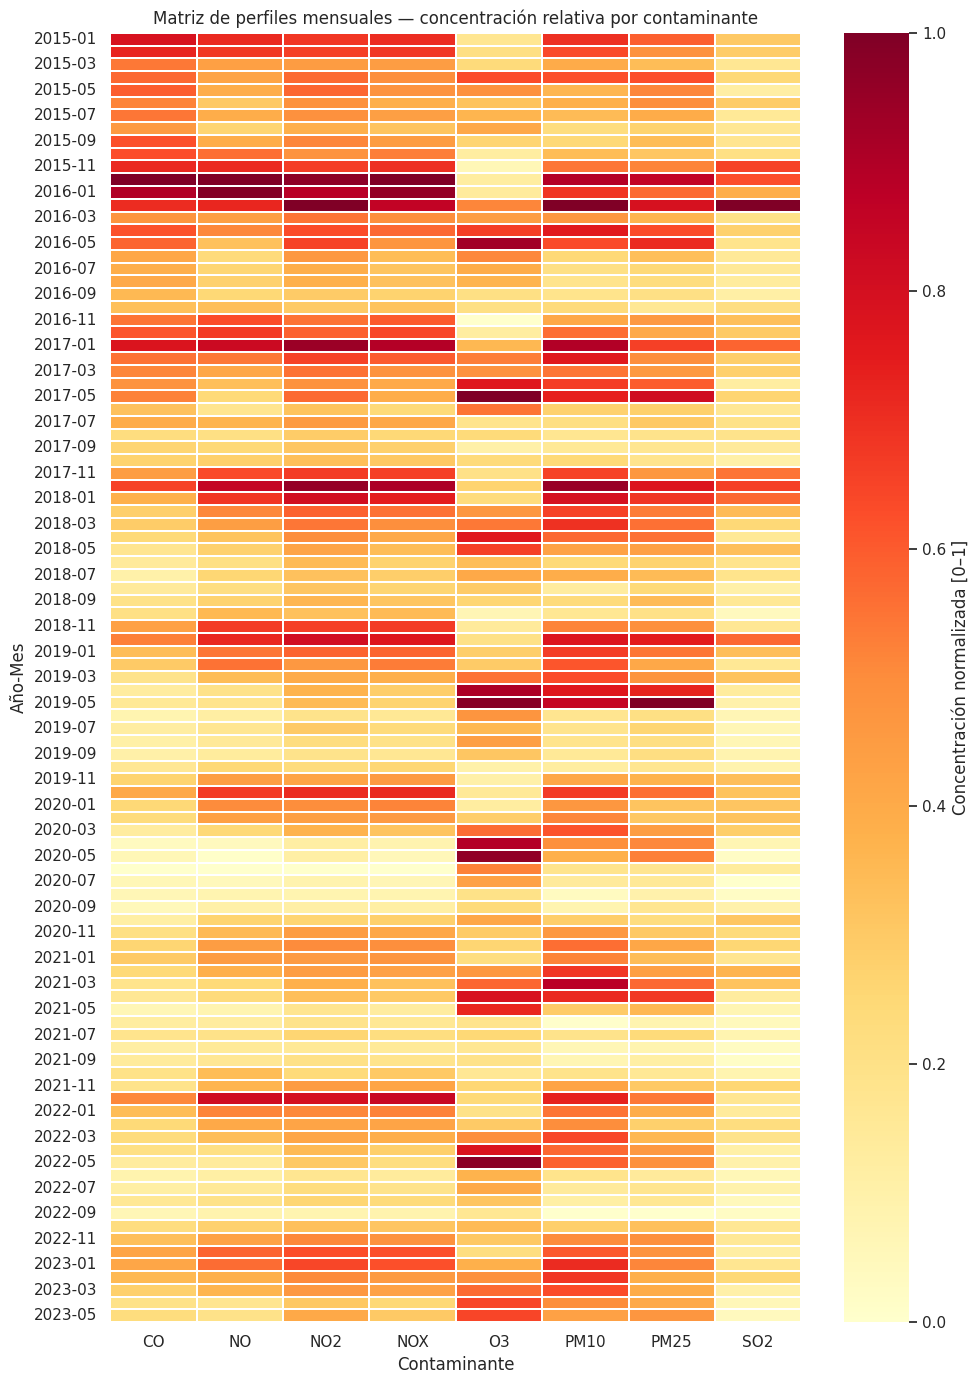

Figura guardada: fig_matriz_mensual.png


In [7]:
# Visualización: heatmap de la matriz M
M_plot = M.copy()
M_plot.index = M_plot.index.astype(str)

# Normalizamos por columna solo para visualización (cada contaminante en su propia escala)
M_viz = (M_plot - M_plot.min()) / (M_plot.max() - M_plot.min())

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(M_viz, cmap='YlOrRd', linewidths=0.1, ax=ax,
            cbar_kws={'label': 'Concentración normalizada [0–1]'})
ax.set_title('Matriz de perfiles mensuales — concentración relativa por contaminante', fontsize=12)
ax.set_xlabel('Contaminante')
ax.set_ylabel('Año-Mes')
plt.tight_layout()
plt.savefig('fig_matriz_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_matriz_mensual.png')

## 4. Manejo de errores y valores faltantes

Aunque el dataset no tiene NaN estructurales, verificamos exhaustivamente
y analizamos los tipos de error que *podrían* ocurrir en este tipo de datos.

In [9]:
# Verificación de NaN
nan_counts = df[CONTAMINANTES].isna().sum()
print('Valores NaN por contaminante:')
print(nan_counts)
print(f'\nTotal NaN en el dataset: {nan_counts.sum()}')
print('\nEl dataset no presenta valores faltantes')
print('Esto indica que SEDEMA ya aplicó imputación antes de publicar los promedios diarios.')

Valores NaN por contaminante:
CO      0
NO      0
NO2     0
NOX     0
O3      0
PM10    0
PM25    0
SO2     0
dtype: int64

Total NaN en el dataset: 0

El dataset no presenta valores faltantes
Esto indica que SEDEMA ya aplicó imputación antes de publicar los promedios diarios.


In [10]:
# Clasificación de tipos de error en datos de calidad del aire
print('Tipos de error comunes en datos de monitoreo atmosférico:')
print()
tipos_error = pd.DataFrame({
    'Tipo':        ['Error sistemático', 'Error aleatorio', 'Error de sensor', 'Valor atípico real'],
    'Descripción': [
        'Sensor descalibrado → todos los valores del período son incorrectos',
        'Interferencia puntual → NaN o valor erróneo en horas aisladas',
        'Sensor fuera de rango → valores negativos o extremadamente altos',
        'Contingencia ambiental real → valor alto legítimo, no es error'
    ],
    'Tratamiento': [
        'Exclusión del período o corrección con datos de otras estaciones',
        'Interpolación lineal (límite: 6 horas consecutivas)',
        'Reemplazar por NaN; tratar como error aleatorio',
        'Conservar; marcar como evento de alta concentración'
    ]
})
print(tipos_error.to_string(index=False))

Tipos de error comunes en datos de monitoreo atmosférico:

              Tipo                                                         Descripción                                                      Tratamiento
 Error sistemático Sensor descalibrado → todos los valores del período son incorrectos Exclusión del período o corrección con datos de otras estaciones
   Error aleatorio       Interferencia puntual → NaN o valor erróneo en horas aisladas              Interpolación lineal (límite: 6 horas consecutivas)
   Error de sensor    Sensor fuera de rango → valores negativos o extremadamente altos                  Reemplazar por NaN; tratar como error aleatorio
Valor atípico real      Contingencia ambiental real → valor alto legítimo, no es error              Conservar; marcar como evento de alta concentración


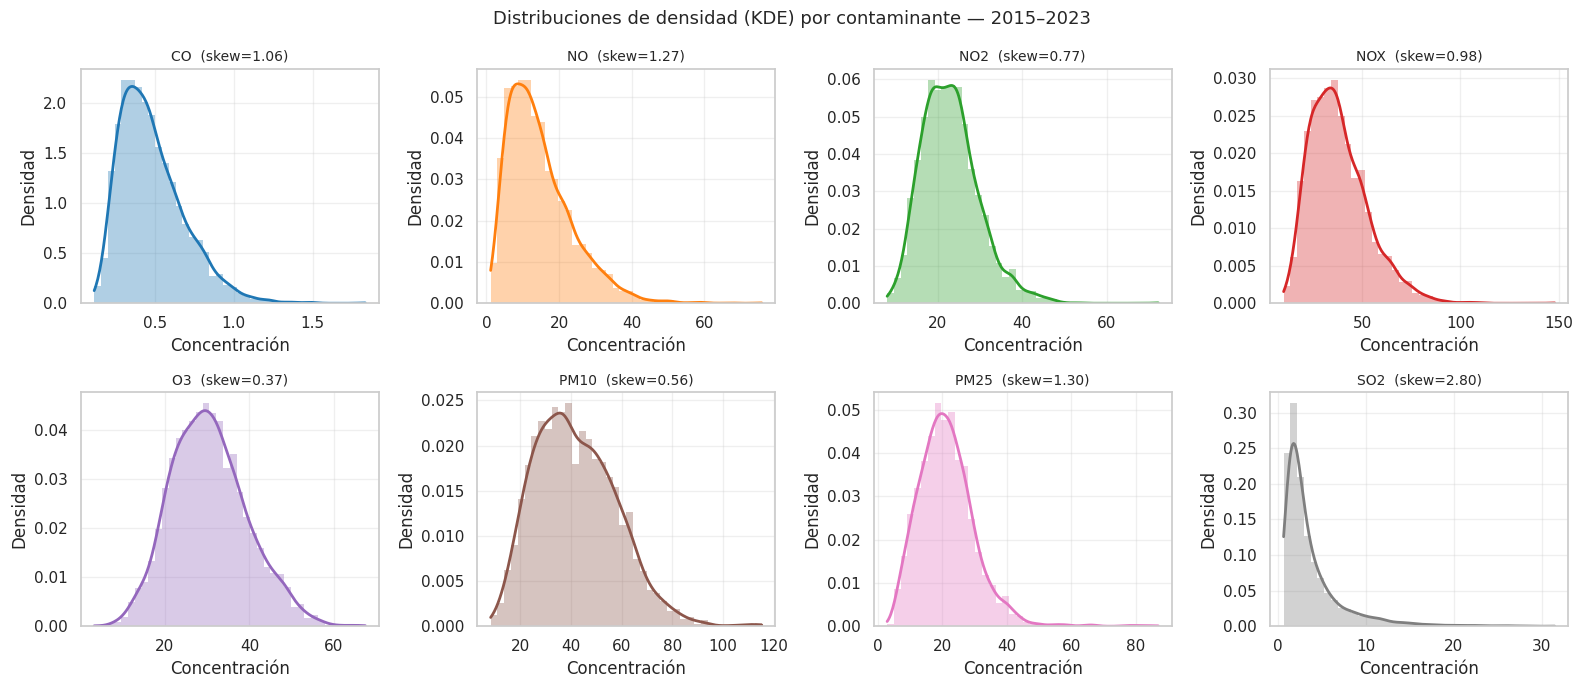

Figura guardada: fig_kde_contaminantes.png


In [11]:
# Distribución de densidad (KDE) por contaminante
# Similar a la Práctica 2: visualizamos la distribución real de cada variable

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

colores = sns.color_palette('tab10', len(CONTAMINANTES))

for ax, cont, color in zip(axes, CONTAMINANTES, colores):
    vals = df[cont].dropna()
    ax.hist(vals, bins=40, density=True, alpha=0.35, color=color, edgecolor='none')
    kde = stats.gaussian_kde(vals)
    xs  = np.linspace(vals.min(), vals.max(), 300)
    ax.plot(xs, kde(xs), color=color, lw=2)
    sk = stats.skew(vals)
    ax.set_title(f'{cont}  (skew={sk:.2f})', fontsize=10)
    ax.set_xlabel('Concentración')
    ax.set_ylabel('Densidad')

plt.suptitle('Distribuciones de densidad (KDE) por contaminante — 2015–2023', fontsize=13)
plt.tight_layout()
plt.savefig('fig_kde_contaminantes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_kde_contaminantes.png')

## 5. Medidas de disimilitud y norma matricial

Calculamos la **distancia euclidiana** entre perfiles mensuales para
cuantificar qué tan distintos son los meses entre sí.

In [12]:
# Etandarizar la matriz M antes de calcular distancias
# Las unidades son distintas (ppm vs ppb vs µg/m³), estandarizar es obligatorio
scaler = StandardScaler()
M_std = pd.DataFrame(
    scaler.fit_transform(M),
    index=M.index,
    columns=M.columns
)

print('Matriz M estandarizada (Z-score):')
print(f'  Media por columna : {M_std.mean().round(6).to_dict()}')
print(f'  Std  por columna  : {M_std.std().round(4).to_dict()}')

Matriz M estandarizada (Z-score):
  Media por columna : {'CO': 0.0, 'NO': -0.0, 'NO2': 0.0, 'NOX': 0.0, 'O3': -0.0, 'PM10': -0.0, 'PM25': -0.0, 'SO2': -0.0}
  Std  por columna  : {'CO': 1.005, 'NO': 1.005, 'NO2': 1.005, 'NOX': 1.005, 'O3': 1.005, 'PM10': 1.005, 'PM25': 1.005, 'SO2': 1.005}


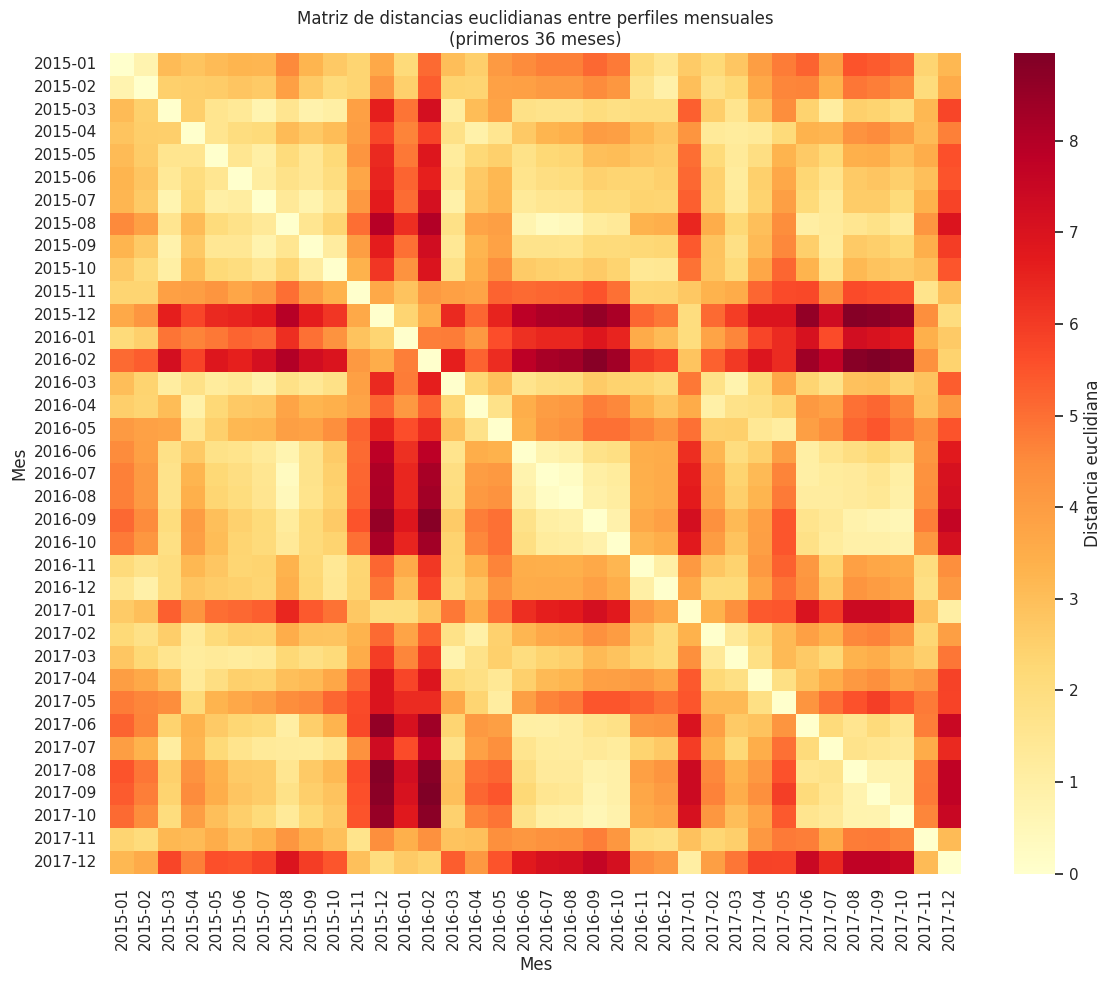

Figura guardada: fig_dist_euclidiana.png


In [13]:
# Matriz de distancias euclidianas entre meses
dist_matrix = pd.DataFrame(
    squareform(pdist(M_std.values, metric='euclidean')),
    index=M_std.index.astype(str),
    columns=M_std.index.astype(str)
).round(4)

# Visualizamos solo una ventana de 36 meses para legibilidad
ventana = 36
dist_plot = dist_matrix.iloc[:ventana, :ventana]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(dist_plot, cmap='YlOrRd', ax=ax, linewidths=0.0,
            cbar_kws={'label': 'Distancia euclidiana'})
ax.set_title(f'Matriz de distancias euclidianas entre perfiles mensuales\n(primeros {ventana} meses)', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Mes')
plt.tight_layout()
plt.savefig('fig_dist_euclidiana.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_dist_euclidiana.png')

In [14]:
# Normas matriciales
D = dist_matrix.values

norma_frobenius = np.linalg.norm(D, 'fro')
norma_espectral = np.linalg.norm(D, 2)
norma_nuclear   = np.linalg.norm(D, 'nuc')
norma_1         = np.linalg.norm(D, 1)   # max suma de columnas
norma_inf       = np.linalg.norm(D, np.inf)  # max suma de filas

print('Normas matriciales de D (distancias euclidianas):')
print(f'  ‖D‖_F  (Frobenius) : {norma_frobenius:.4f}  → magnitud total de disimilitud')
print(f'  ‖D‖_2  (espectral) : {norma_espectral:.4f}  → mayor valor singular')
print(f'  ‖D‖_*  (nuclear)   : {norma_nuclear:.4f}  → suma de valores singulares')
print(f'  ‖D‖_1  (col max)   : {norma_1:.4f}  → mes más disímil en promedio')
print(f'  ‖D‖_∞  (fila max)  : {norma_inf:.4f}  → mes con mayor suma de distancias')

# Identificar el mes más disímil (mayor suma de distancias)
suma_dist = dist_matrix.sum(axis=1)
mes_max = suma_dist.idxmax()
print(f'\nMes más disímil respecto a los demás: {mes_max}  (suma = {suma_dist[mes_max]:.2f})')

Normas matriciales de D (distancias euclidianas):
  ‖D‖_F  (Frobenius) : 404.0001  → magnitud total de disimilitud
  ‖D‖_2  (espectral) : 378.1189  → mayor valor singular
  ‖D‖_*  (nuclear)   : 756.2379  → suma de valores singulares
  ‖D‖_1  (col max)   : 744.4207  → mes más disímil en promedio
  ‖D‖_∞  (fila max)  : 744.4207  → mes con mayor suma de distancias

Mes más disímil respecto a los demás: 2016-02  (suma = 744.42)


## 6. Medidas de similitud

Calculamos tres medidas de similitud entre meses. Para Jaccard y Sørensen-Dice
binarizamos: un mes es **"contaminado"** en un contaminante si su concentración
supera el percentil 75 histórico de ese contaminante.

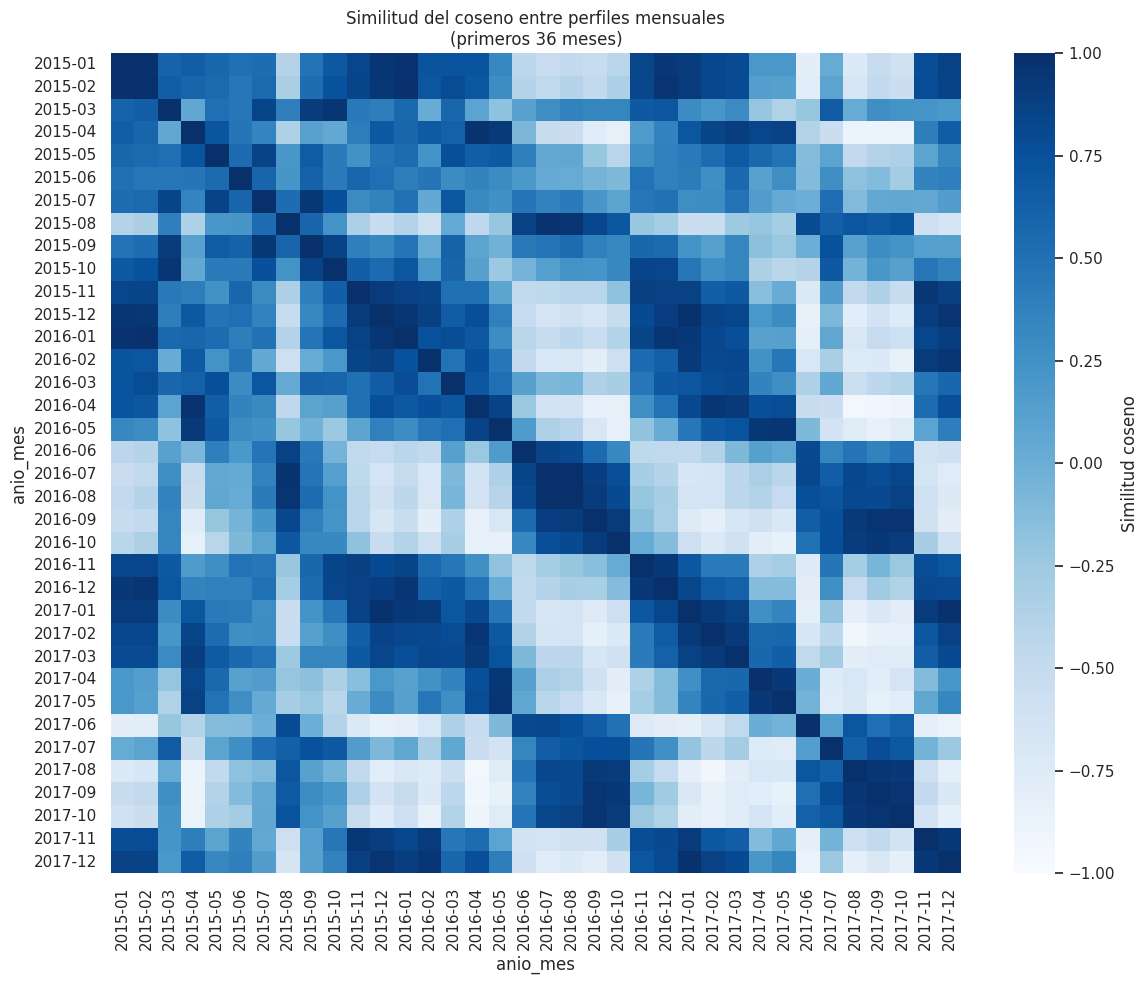

In [15]:
# Similitud del coseno entre perfiles mensuales
sim_cos = pd.DataFrame(
    cosine_similarity(M_std.values),
    index=M_std.index.astype(str),
    columns=M_std.index.astype(str)
).round(4)

# Mostramos solo primeros 36 meses
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_cos.iloc[:ventana, :ventana], cmap='Blues', ax=ax,
            linewidths=0.0, vmin=-1, vmax=1,
            cbar_kws={'label': 'Similitud coseno'})
ax.set_title(f'Similitud del coseno entre perfiles mensuales\n(primeros {ventana} meses)', fontsize=12)
plt.tight_layout()
plt.savefig('fig_similitud_coseno.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Binarización para Jaccard y Sorensen-Dice
# Un mes es "alto" en un contaminante si supera el percentil 75
p75 = M[CONTAMINANTES].quantile(0.75)
M_bin = (M[CONTAMINANTES] > p75).astype(int)

print('Matriz binarizada (1 = mes con alta concentración en ese contaminante):')
print(f'  Shape: {M_bin.shape}')
print(f'  Proporción de 1s por contaminante:')
print((M_bin.mean() * 100).round(1).to_string())

Matriz binarizada (1 = mes con alta concentración en ese contaminante):
  Shape: (101, 8)
  Proporción de 1s por contaminante:
CO      24.8
NO      24.8
NO2     24.8
NOX     24.8
O3      24.8
PM10    24.8
PM25    24.8
SO2     24.8


In [17]:
# Jaccard y Sorensen-Dice
def jaccard(a, b):
    interseccion = np.sum(a & b)
    union        = np.sum(a | b)
    return interseccion / union if union > 0 else 0.0

def sorensen_dice(a, b):
    interseccion = np.sum(a & b)
    denominador  = np.sum(a) + np.sum(b)
    return (2 * interseccion) / denominador if denominador > 0 else 0.0

n = len(M_bin)
jacc_mat = np.zeros((n, n))
dice_mat = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        a = M_bin.values[i]
        b = M_bin.values[j]
        jacc_mat[i, j] = jaccard(a, b)
        dice_mat[i, j] = sorensen_dice(a, b)

idx_str = M_bin.index.astype(str)
jacc_df = pd.DataFrame(jacc_mat, index=idx_str, columns=idx_str).round(4)
dice_df = pd.DataFrame(dice_mat, index=idx_str, columns=idx_str).round(4)

print('Relación teórica: Dice = 2·Jaccard / (1 + Jaccard)  →  Dice ≥ Jaccard siempre')
print()
print(f'Promedio Jaccard (fuera de la diagonal): {jacc_mat[jacc_mat < 1].mean():.4f}')
print(f'Promedio Dice    (fuera de la diagonal): {dice_mat[dice_mat < 1].mean():.4f}')

Relación teórica: Dice = 2·Jaccard / (1 + Jaccard)  →  Dice ≥ Jaccard siempre

Promedio Jaccard (fuera de la diagonal): 0.0741
Promedio Dice    (fuera de la diagonal): 0.1022


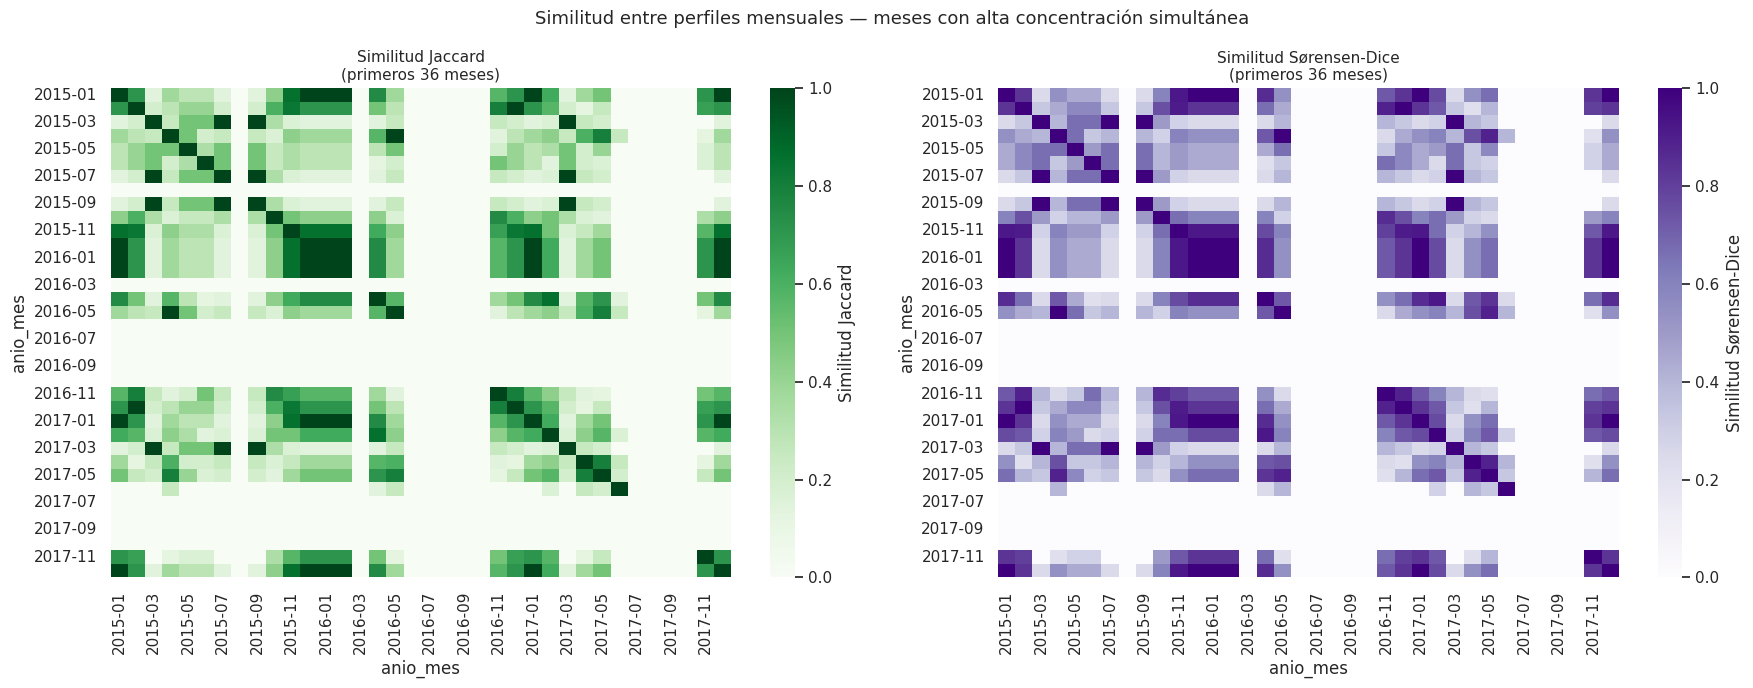

In [18]:
# Visualización comparativa Jaccard vs Dice (primeros 36 meses)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, mat, nombre, cmap in zip(
    axes,
    [jacc_df.iloc[:ventana, :ventana], dice_df.iloc[:ventana, :ventana]],
    ['Jaccard', 'Sørensen-Dice'],
    ['Greens', 'Purples']
):
    sns.heatmap(mat, cmap=cmap, ax=ax, linewidths=0.0, vmin=0, vmax=1,
                cbar_kws={'label': f'Similitud {nombre}'})
    ax.set_title(f'Similitud {nombre}\n(primeros {ventana} meses)', fontsize=11)

plt.suptitle('Similitud entre perfiles mensuales — meses con alta concentración simultánea', fontsize=13)
plt.tight_layout()
plt.savefig('fig_jaccard_dice.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Detección y manejo de outliers

In [19]:
# Método IQR
def detectar_outliers_iqr(serie, factor=1.5):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - factor * IQR
    lim_sup = Q3 + factor * IQR
    return (serie < lim_inf) | (serie > lim_sup), lim_inf, lim_sup

resumen_outliers = []
for cont in CONTAMINANTES:
    mascara, li, ls = detectar_outliers_iqr(df[cont])
    resumen_outliers.append({
        'Contaminante': cont,
        'Lím. inferior': round(li, 3),
        'Lím. superior': round(ls, 3),
        'N outliers':    int(mascara.sum()),
        '% del total':   round(mascara.mean() * 100, 2)
    })

resumen_df = pd.DataFrame(resumen_outliers)
print('Outliers detectados por método IQR (factor = 1.5):')
print(resumen_df.to_string(index=False))

Outliers detectados por método IQR (factor = 1.5):
Contaminante  Lím. inferior  Lím. superior  N outliers  % del total
          CO         -0.077          1.002          55         1.79
          NO         -9.032         36.437          74         2.41
         NO2          5.190         39.853          59         1.92
         NOX         -2.764         76.442          50         1.63
          O3          5.484         54.655          23         0.75
        PM10         -5.353         87.546          20         0.65
        PM25         -0.958         42.515          51         1.66
         SO2         -2.673          8.607         255         8.30


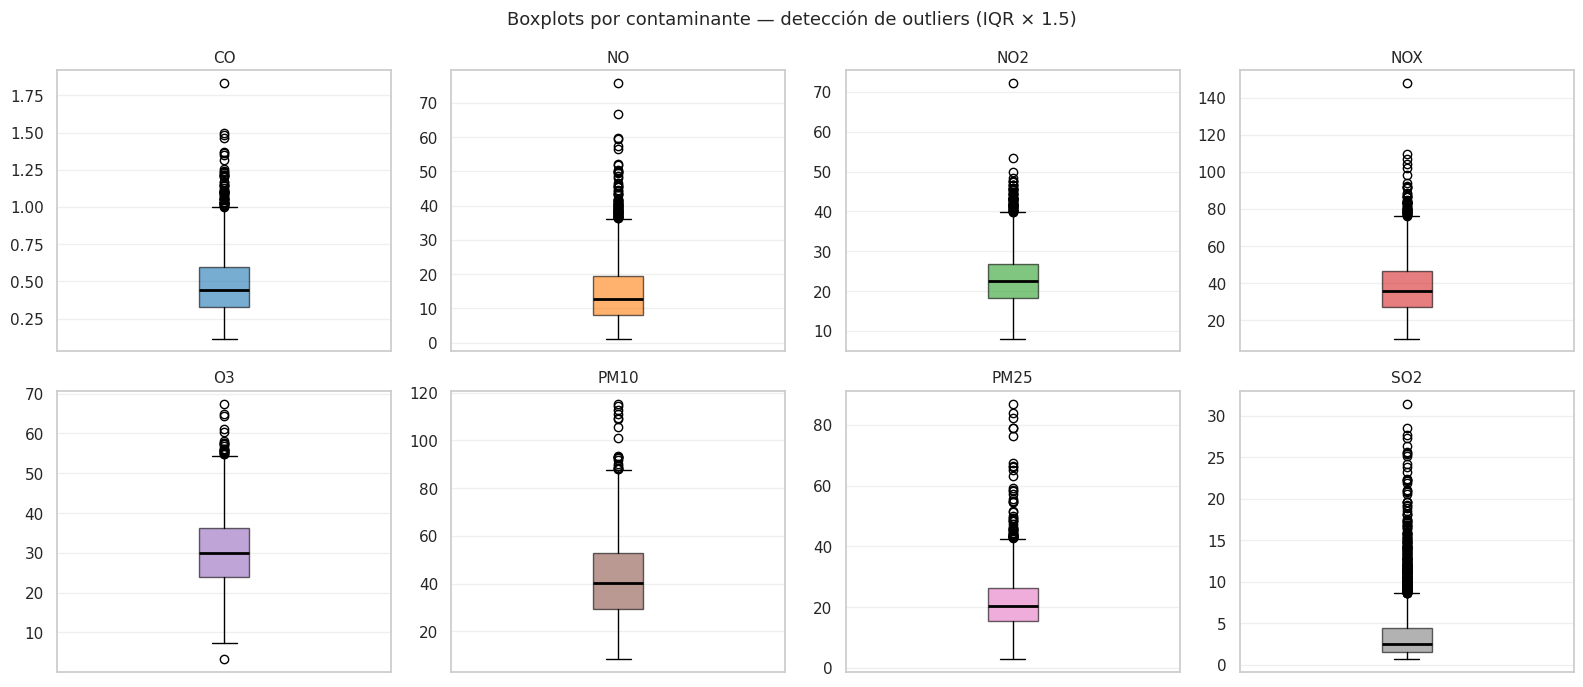

In [20]:
# Boxplots de todos los contaminantes
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colores = sns.color_palette('tab10', len(CONTAMINANTES))

for ax, cont, color in zip(axes, CONTAMINANTES, colores):
    bp = ax.boxplot(df[cont].dropna(), patch_artist=True, vert=True,
                    medianprops=dict(color='black', lw=2),
                    boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(cont, fontsize=11)
    ax.set_xticks([])

plt.suptitle('Boxplots por contaminante — detección de outliers (IQR × 1.5)', fontsize=13)
plt.tight_layout()
plt.savefig('fig_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Estrategia de tratamiento
# Los outliers en calidad del aire SON eventos reales (contingencias ambientales)
# → Se conservan y se etiquetan como eventos de alta concentración

for cont in CONTAMINANTES:
    mascara, _, _ = detectar_outliers_iqr(df[cont])
    df[f'{cont}_outlier'] = mascara.astype(int)

# Columna resumen: ¿algún contaminante en estado de outlier ese día?
cols_outlier = [f'{c}_outlier' for c in CONTAMINANTES]
df['evento_extremo'] = (df[cols_outlier].sum(axis=1) > 0).astype(int)

print(f'Días con al menos un contaminante en estado outlier: {df["evento_extremo"].sum():,}'
      f' ({df["evento_extremo"].mean()*100:.1f}% del total)')
print()
print('Decisión: se conservan todos los valores.')
print('La columna "evento_extremo" se usará en el dashboard para destacar contingencias.')

Días con al menos un contaminante en estado outlier: 379 (12.3% del total)

Decisión: se conservan todos los valores.
La columna "evento_extremo" se usará en el dashboard para destacar contingencias.


## 8. Filtrado de señales

Aplicamos un **filtro Butterworth paso-bajas** sobre la serie temporal diaria
para separar la tendencia de largo plazo del ruido de alta frecuencia.

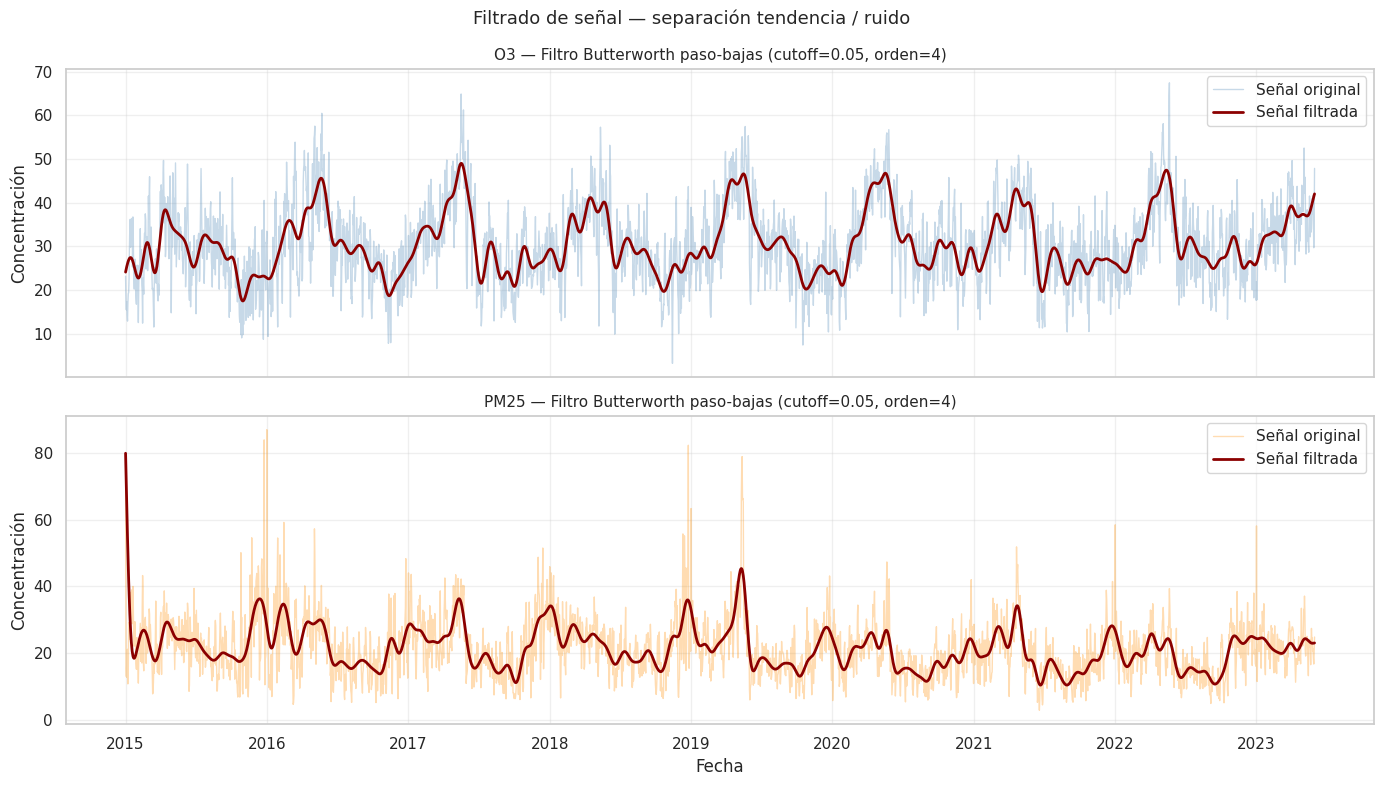

In [22]:
from scipy.signal import butter, filtfilt

def filtro_butterworth(serie, cutoff=0.05, orden=4):
    """
    Filtro paso-bajas Butterworth.
    cutoff: fracción de la frecuencia de Nyquist (0 < cutoff < 1)
    Valores bajos de cutoff → suavizado más agresivo (tendencia de largo plazo)
    """
    b, a = butter(orden, cutoff, btype='low', analog=False)
    return filtfilt(b, a, serie)

# Aplicamos a todos los contaminantes
for cont in CONTAMINANTES:
    df[f'{cont}_filtrado'] = filtro_butterworth(df[cont].values, cutoff=0.05)

# Visualizamos para O3 y PM25 como ejemplo
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, cont, color in zip(axes, ['O3', 'PM25'], ['steelblue', 'darkorange']):
    ax.plot(df['fecha'], df[cont], alpha=0.3, lw=1, color=color, label='Señal original')
    ax.plot(df['fecha'], df[f'{cont}_filtrado'], lw=2, color='darkred', label='Señal filtrada')
    ax.set_ylabel('Concentración')
    ax.set_title(f'{cont} — Filtro Butterworth paso-bajas (cutoff=0.05, orden=4)', fontsize=11)
    ax.legend()

axes[-1].set_xlabel('Fecha')
plt.suptitle('Filtrado de señal — separación tendencia / ruido', fontsize=13)
plt.tight_layout()
plt.savefig('fig_filtro.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Transformación y normalización

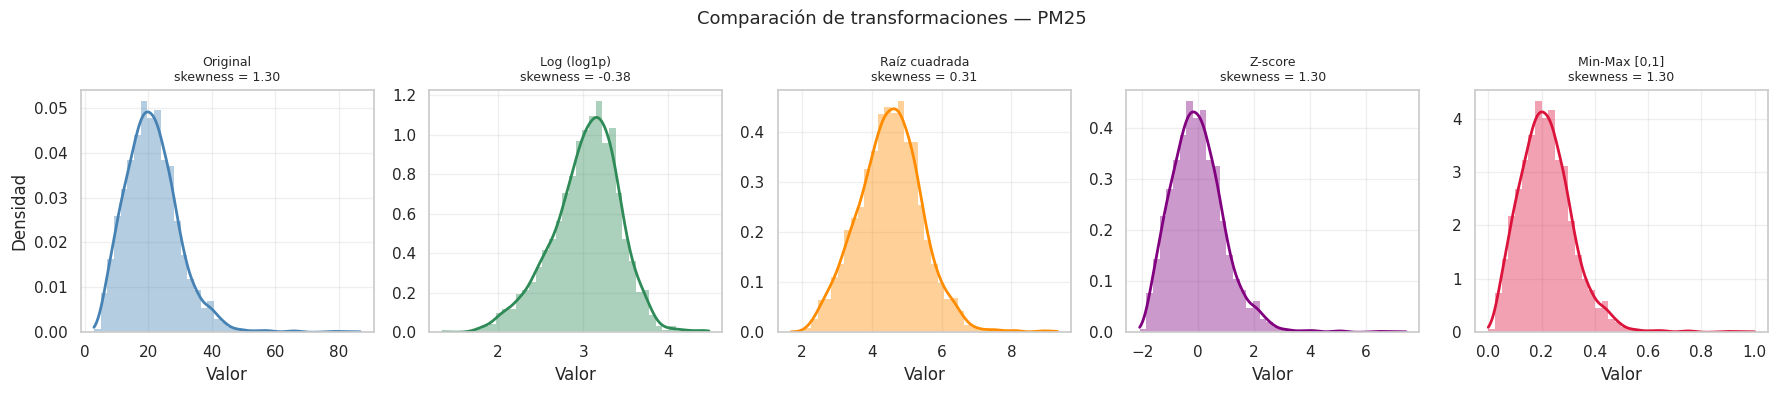

La transformación log reduce la asimetría positiva (skew) del PM25


In [23]:
# Comparación de transformaciones sobre PM25
cont_demo = 'PM25'
vals = df[cont_demo].dropna()

transformaciones = {
    'Original':        vals,
    'Log (log1p)':     np.log1p(vals),
    'Raíz cuadrada':   np.sqrt(vals),
    'Z-score':         (vals - vals.mean()) / vals.std(),
    'Min-Max [0,1]':   (vals - vals.min()) / (vals.max() - vals.min())
}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colores_t = ['steelblue', 'seagreen', 'darkorange', 'purple', 'crimson']

for ax, (nombre, v), color in zip(axes, transformaciones.items(), colores_t):
    ax.hist(v, bins=40, density=True, color=color, alpha=0.4, edgecolor='none')
    kde = stats.gaussian_kde(v.dropna())
    xs  = np.linspace(v.min(), v.max(), 200)
    ax.plot(xs, kde(xs), color=color, lw=2)
    sk  = stats.skew(v.dropna())
    ax.set_title(f'{nombre}\nskewness = {sk:.2f}', fontsize=9)
    ax.set_xlabel('Valor')

axes[0].set_ylabel('Densidad')
plt.suptitle(f'Comparación de transformaciones — {cont_demo}', fontsize=13)
plt.tight_layout()
plt.savefig('fig_transformaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print('La transformación log reduce la asimetría positiva (skew) del PM25')

In [24]:
# Aplicar Z-score a la matriz de perfiles mensuales
# Esta versión normalizada se exporta para usar en PCA, MDS y Sammon en el dashboard
M_std_export = pd.DataFrame(
    StandardScaler().fit_transform(M),
    index=M.index,
    columns=M.columns
).round(6)

print('Matriz M estandarizada lista para PCA y MDS:')
print(f'  Shape : {M_std_export.shape}')
M_std_export.head()

Matriz M estandarizada lista para PCA y MDS:
  Shape : (101, 8)


,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
anio_mes,,,,,,,,
2015-01,2.178096,1.606863,1.165041,1.421673,-0.928885,1.028664,0.996444,0.545306
2015-02,1.878697,1.451142,1.058567,1.282872,-0.739800,0.773956,0.435022,0.474642
2015-03,1.011576,0.328331,0.056534,0.189543,-0.638172,-0.192404,-0.292941,-0.284924
2015-04,1.175319,0.273585,0.619408,0.408274,1.028620,0.719654,1.188295,0.224924
2015-05,1.286473,0.125673,0.660703,0.341408,0.425886,-0.345246,0.595185,-0.551006


## 10. Construcción de perfiles mensuales

Generamos los datasets auxiliares que usará el dashboard:
perfil por mes del año (enero–diciembre) y perfil por año.

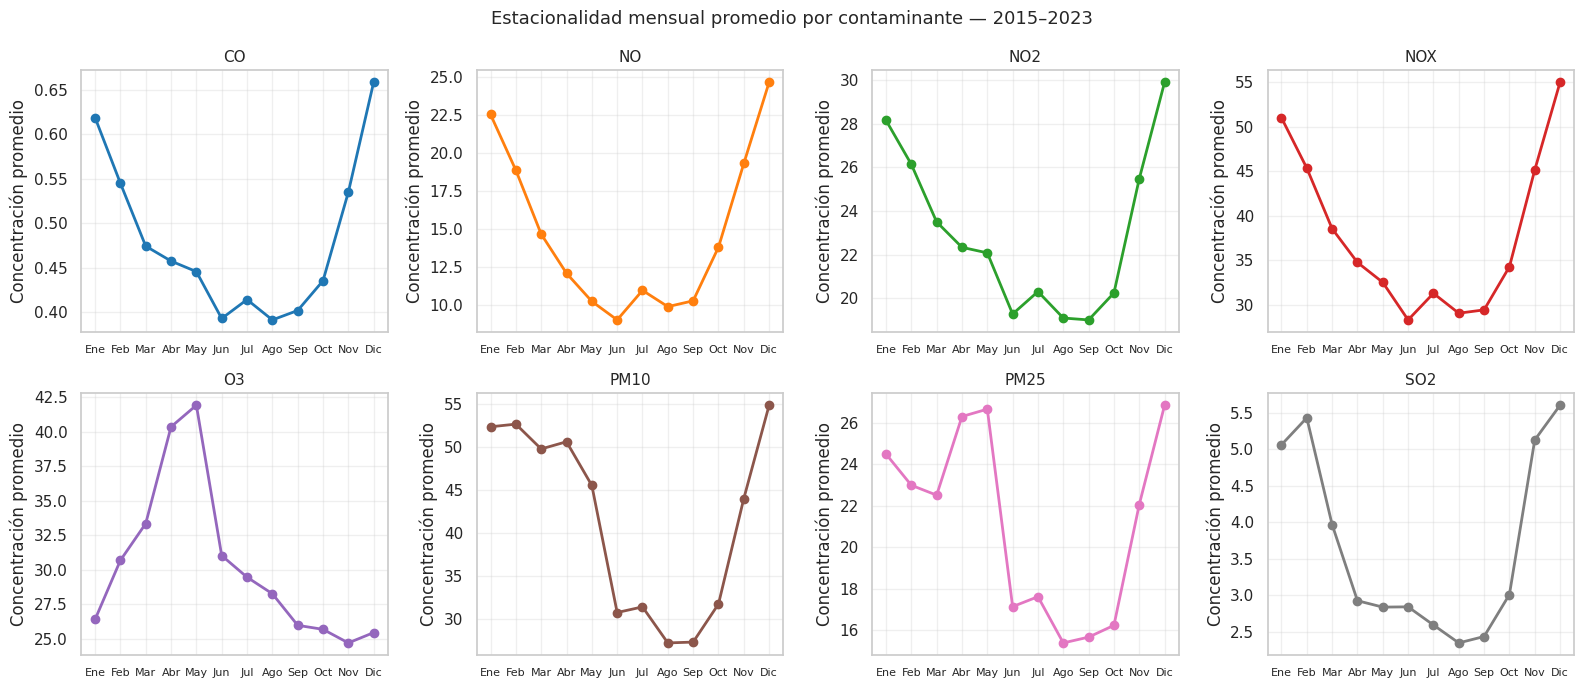

Figura guardada: fig_estacionalidad.png


In [25]:
# Perfil mensual del año (promedio de cada mes sobre todos los años)
perfil_mes = df.groupby('mes')[CONTAMINANTES].mean().round(4)
perfil_mes.index.name = 'mes'
nombres_mes = {1:'Ene',2:'Feb',3:'Mar',4:'Abr',5:'May',6:'Jun',
               7:'Jul',8:'Ago',9:'Sep',10:'Oct',11:'Nov',12:'Dic'}
perfil_mes['mes_nombre'] = perfil_mes.index.map(nombres_mes)

# Perfil anual
perfil_anio = df.groupby('anio')[CONTAMINANTES].mean().round(4)

# Visualización del perfil mensual
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
colores = sns.color_palette('tab10', len(CONTAMINANTES))

for ax, cont, color in zip(axes, CONTAMINANTES, colores):
    ax.plot(perfil_mes.index, perfil_mes[cont], marker='o', color=color, lw=2)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(list(nombres_mes.values()), fontsize=8)
    ax.set_title(cont, fontsize=11)
    ax.set_ylabel('Concentración promedio')

plt.suptitle('Estacionalidad mensual promedio por contaminante — 2015–2023', fontsize=13)
plt.tight_layout()
plt.savefig('fig_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: fig_estacionalidad.png')

## 11. Exportación de datasets procesados

In [26]:
# Dataset principal limpio con columnas auxiliares
df.to_csv('rama_clean.csv', index=False)

# Matriz de perfiles mensuales (cruda y estandarizada)
M.index = M.index.astype(str)
M.to_csv('perfil_mensual.csv')

M_std_export.index = M_std_export.index.astype(str)
M_std_export.to_csv('perfil_mensual_std.csv')

# Perfiles de estacionalidad
perfil_mes.to_csv('perfil_por_mes.csv')
perfil_anio.to_csv('perfil_por_anio.csv')

# Matrices de similitud/disimilitud
dist_matrix.to_csv('distancia_euclidiana_meses.csv')
sim_cos.to_csv('similitud_coseno_meses.csv')
jacc_df.to_csv('jaccard_meses.csv')
dice_df.to_csv('dice_meses.csv')

archivos = [
    'rama_clean.csv', 'perfil_mensual.csv', 'perfil_mensual_std.csv',
    'perfil_por_mes.csv', 'perfil_por_anio.csv',
    'distancia_euclidiana_meses.csv', 'similitud_coseno_meses.csv',
    'jaccard_meses.csv', 'dice_meses.csv'
]

print('Archivos exportados:')
for f in archivos:
    print(f'  {f}')

print('\nTodos los archivos están listos para el dashboard de Streamlit')

Archivos exportados:
  ✓ rama_clean.csv
  ✓ perfil_mensual.csv
  ✓ perfil_mensual_std.csv
  ✓ perfil_por_mes.csv
  ✓ perfil_por_anio.csv
  ✓ distancia_euclidiana_meses.csv
  ✓ similitud_coseno_meses.csv
  ✓ jaccard_meses.csv
  ✓ dice_meses.csv

Todos los archivos están listos para el dashboard de Streamlit ✓


---
## Resumen del preprocesamiento

| # | Paso realizado | Técnica | Tema del curso |
|---|---------------|---------|----------------|
| 1 | Clasificación de variables | Escalas nominal, intervalo, razón | Escalas de datos |
| 2 | Construcción M (meses × contaminantes) | Agregación y pivoteo | Sets de matrices |
| 3 | Identificación de tipos de error | Sistemático vs aleatorio vs atípico real | Tipos de errores |
| 4 | Distribuciones de densidad (KDE) | Kernel Density Estimation | Manejo de errores |
| 5 | Distancia euclidiana entre meses | d(x,y) = ‖x−y‖₂ sobre M estandarizada | Medidas de disimilitud |
| 6 | Normas matriciales (Frobenius, espectral, nuclear) | ‖A‖_F, ‖A‖_2, ‖A‖_* | Norma matricial |
| 7 | Similitud del coseno entre meses | cos(θ) = xᵀy / (‖x‖·‖y‖) | Similitud del coseno |
| 8 | Similitud de Jaccard y Sørensen-Dice | Sobre vectores binarios (p75) | Jaccard y Sørensen-Dice |
| 9 | Detección de outliers + boxplots | Método IQR (factor 1.5) | Manejo de outliers |
| 10 | Filtro paso-bajas Butterworth | filtfilt(b, a, x) | Filtros |
| 11 | Transformaciones: log, sqrt, Z-score, Min-Max | Reducción de asimetría | Transformación de datos |